In [1]:
### plot Fig 1 example DRG unit raster and RF - BPV4

In [2]:
import numpy as np
import os
import pickle
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

import matplotlib

matplotlib.rcParams['font.size'] = 7
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['font.sans-serif'] = 'Arial'

In [3]:
dir = os.getcwd()
base_dir = os.path.dirname(dir)
data_dir = os.path.join(base_dir, 'data')

In [4]:
# 2-40 Hz laser train "opto" - load data
drg_spktime_opto_file = os.path.join(data_dir, 'drg_spktime_opto.npy')
drg_trig_time_opto_file = os.path.join(data_dir, 'drg_trig_time_opto.npy')
spktime_s = np.load(drg_spktime_opto_file)
trig_start_time = np.load(drg_trig_time_opto_file)

In [5]:
# laser/LED time for optotagging (from ChR2 optotagging so it is called LED)
ntrials = 10
### time of LED onset in each trial
LED_freq = [2,5,10,20,40]
LED_start_time = np.array([])
for ifreq in range(len(LED_freq)):
    ifreq_LED = LED_freq[ifreq]
    ifreq_time = np.linspace(ifreq*2, ifreq*2 + 2, ifreq_LED * 2, endpoint=False)
    LED_start_time = np.concatenate((LED_start_time, ifreq_time))

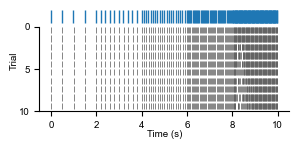

In [6]:
ntrials = 10     
y_trial = 0  
spk_time_trials = []

fig, ax = plt.subplots(figsize = (3,1.5))
for itrial in np.arange(0,ntrials):
    itrial_trig_start = trig_start_time[itrial]
    itrial_trig_end = itrial_trig_start + 12.5
    ispk_time_itrial = spktime_s[(spktime_s>itrial_trig_start)&(spktime_s<itrial_trig_end)] - itrial_trig_start
    ax.vlines(ispk_time_itrial - 1, y_trial, y_trial+0.75, color = "#555555", linewidth= 0.5)

    y_trial += 1

    spk_time_trials.append(ispk_time_itrial-1)

ax.vlines(LED_start_time, ymin = -2, ymax = -0.5, linewidth=1, zorder = 101)

    
ax.set_xlim(-0.5,10.5)
ax.set_ylim(-2,10)
ax.set_xlabel('Time (s)',labelpad=0)
ax.set_ylabel('Trial',labelpad=0)

ax.set_yticks([0,5,10])
ax.set_yticklabels([0,5,10])

ax.spines['left'].set_bounds((0, 10))
ax.spines['bottom'].set_zorder(0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.invert_yaxis()

plt.tight_layout()

plt.show()



In [7]:
# 20 Hz irregular 'sync' - load data 

drg_spktime_sync_file = os.path.join(data_dir, 'drg_spktime_sync.npy')
drg_trig_time_sync_file = os.path.join(data_dir, 'drg_trig_time_sync.npy')
spktime_s = np.load(drg_spktime_sync_file)
trig_start_time = np.load(drg_trig_time_sync_file)

In [8]:
# load time (in samples) for sync trace0
laser_samp_dir = os.path.join(data_dir, 'sync_samp')
sync0_samp_file = 'sync_samp_set0.npy'

laser_samp_sync0_file = os.path.join(laser_samp_dir, sync0_samp_file)
laser_samp_sync0 = np.load(laser_samp_sync0_file)

laser_time_sync_trace0 = laser_samp_sync0[0] / 30000 # for NPx sampling rate=30000

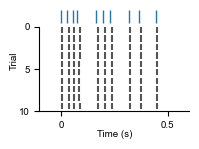

In [9]:
ntrials = 30     
y_trial = 0  

fig, ax = plt.subplots(figsize = (2,1.5))
for itrial in np.arange(0,ntrials):
    itrial_trig_start = trig_start_time[itrial]
    itrial_trig_end = itrial_trig_start + 1.5
    ispk_time_itrial = spktime_s[(spktime_s>itrial_trig_start)&(spktime_s<itrial_trig_end)] - itrial_trig_start
    ax.vlines(ispk_time_itrial - 1, y_trial, y_trial+0.75, color="#555555")

    # ax.scatter(ispk_time_itrial,np.repeat(y_trial, len(ispk_time_itrial)), marker = '|', color = 'black', alpha = 0.7)
    # plt.vlines(np.arange(1,11) ,0, ntrials, linestyles= ':', linewidth = 0.5, alpha = 0.3)
    y_trial += 1
    
    
ax.vlines(laser_time_sync_trace0, ymin = -2, ymax = -0.5, linewidth=1, zorder = 101)
    
ax.set_xlim(-0.1,0.6)
ax.set_ylim(-2,10)
ax.set_xlabel('Time (s)',labelpad=0)
ax.set_ylabel('Trial',labelpad=0)

ax.set_yticks([0,5,10])
ax.set_yticklabels([0,5,10])

ax.set_xticks([0,0.5])
ax.set_xticklabels([0,0.5])

ax.spines['left'].set_bounds((0, 10))
ax.spines['bottom'].set_zorder(0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.invert_yaxis()

plt.tight_layout()
plt.show()


In [10]:
# Receptive field with 40 Hz laser train
# rf_spk_count = iunit_spk_count_xy
# psth_laser = iunit_psth_laser1_array

rf_spk_count_file = os.path.join(data_dir, 'DRG_RF_spkcount_40Hz.npy')
rf_psth_file = os.path.join(data_dir, 'DRG_RF_psth_40Hz.npy').replace('\\','/')
trig_start_samp_file = os.path.join(data_dir, 'DRG_RF_40Hz_trig_start_samp.npy').replace('\\','/')
RF_spk_samp_file = os.path.join(data_dir, 'DRG_RF_40Hz_spk_samp.npy').replace('\\','/')

rf_spk_count = np.load(rf_spk_count_file)
psth_laser = np.load(rf_psth_file)
trig_start_samp = np.load(trig_start_samp_file)
RF_spk_samp = np.load(RF_spk_samp_file)

In [11]:
rf_trial_file = os.path.join(data_dir, 'DRG_RF_trial.pickle')
with open(rf_trial_file, 'rb') as handle:
    rf_trial = pickle.load(handle)
    
nx = rf_trial['nx']
ny = rf_trial['ny']
ntrial_idx = rf_trial['ntrial_idx']
dtbin = rf_trial['dtbin']

(600,)
(30, 20)


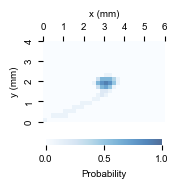

In [12]:
# rotate xy axis
twin_laser = np.arange(500,1000)

for i in range(1):

    iunit_psth_laser_rf_array = psth_laser

    iunit_fr_xy = np.zeros((nx, ny))

    iunit_fr_bytrial = np.mean(iunit_psth_laser_rf_array[:, twin_laser], axis=1)
    print(iunit_fr_bytrial.shape)
    # print(iunit_fr_bytrial.shape)
    iunit_fr_cond = np.zeros((nx*ny,1))

    for icond_idx in range(nx*ny): # for each x&y combination condition
        # print(icond_idx)
        icond_trial_idx = np.where(ntrial_idx == icond_idx)[0]
        # print(icond_trial_idx)
        # print(iunit_fr_bytrial[icond_trial_idx])
        icond_fr = np.mean(iunit_fr_bytrial[icond_trial_idx])
        # print(icond_fr)
        iunit_fr_cond[icond_idx,0] = icond_fr
        # print(icond_trial_idx)
    iunit_fr_xy = iunit_fr_cond.reshape(nx,ny)
    print(iunit_fr_xy.shape)
    iunit_spk_count_xy = iunit_fr_xy * dtbin * len(twin_laser)

    fig, ax = plt.subplots(figsize = (3,1.5))
    ax = sns.heatmap(iunit_spk_count_xy.T/10, vmin=0, vmax=1, cmap = 'Blues',alpha = 0.7, cbar_kws={'label': 'Probability', 'location':'bottom',"shrink": 0.5})
    # ax = sns.heatmap(iunit_spk_count_xy, cmap = 'Blues')

    # ax.invert_yaxis()
    # plt.title(str(i)+' Unit'+str(iunit))
    ax.set_xlabel('x (mm)')
    ax.set_ylabel('y (mm)')
    ax.set_aspect('equal')
    ax.xaxis.set_label_position('top') # Move the *axis title* to the top
    ax.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)

    ax.set_yticks([0,5,10,15,20])
    ax.set_yticklabels([4,3,2,1,0])

    ax.set_xticks([0,5,10,15,20,25,30])
    ax.set_xticklabels([0,1,2,3,4,5,6])
    
    # plt.tight_layout()

    plt.show()


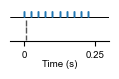

In [13]:
# plot the raster of 3 at axon fiber
fs = 20000
laser_pulse_samp = np.linspace(0, 0.25*fs, int(40*0.25), endpoint=False)

x_idx1 = np.array([4,5,5])
y_idx1 = np.array([18,18,17])

iunit_spk_idx1 = []
y_trial = 0

dtbin = 1/1000 # 1ms bin
trial_start = -500/1000 # start time of each trial
trial_end = 500/1000
tbin_trial = np.linspace(trial_start, trial_end, int((trial_end-trial_start)/dtbin)+1, endpoint=True)

dtbin_fs = dtbin * fs
trial_start_fs = trial_start * fs
trial_end_fs = trial_end * fs
tbin_trial_fs = np.linspace(trial_start_fs, trial_end_fs, int((trial_end_fs-trial_start_fs)/dtbin_fs)+1, endpoint=True)

fig, ax = plt.subplots(figsize = (1.2,0.8))
for i in range(3): # for each x&y combination condition
    # print(icond_idx)

    itrial_idx = np.ravel_multi_index((x_idx1[i], y_idx1[i]), (nx, ny))

    icond_trial_idx = np.where(ntrial_idx == itrial_idx)[0]

    iunit_spk_samp = RF_spk_samp

    itrial_trig_start = trig_start_samp[icond_trial_idx] + trial_start_fs
    itrial_trig_end = trig_start_samp[icond_trial_idx] + trial_end_fs
    ispk_samp_itrial = iunit_spk_samp[(iunit_spk_samp>itrial_trig_start)&(iunit_spk_samp<itrial_trig_end)] - trig_start_samp[icond_trial_idx]
    
    iunit_spk_idx1.append(ispk_samp_itrial)

    ax.vlines(ispk_samp_itrial, y_trial, y_trial+0.75, color = '#555555', linewidth=1)
    y_trial += 1
    ax.hlines(-0.5, xmin=-1000, xmax=6000,  color = 'black', linewidth=0.5)

    ax.vlines(laser_pulse_samp, ymin = -1.25, ymax = -0.5, linewidth=1, zorder = 101)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_yticks([])
    ax.set_yticklabels([])
    ax.spines['left'].set_visible(False)

    ax.set_xlim(-1000,6000)
    ax.set_xticks([0,5000])
    ax.set_xticks([0,5000])
    ax.set_xticklabels([0,0.25])
    ax.set_xlabel('Time (s)',labelpad=0)
    ax.spines['left'].set_bounds((0, 3))
    ax.invert_yaxis()
    plt.tight_layout()


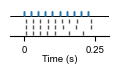

In [14]:
# plot the raster of 3 at axon terminal
laser_pulse_samp = np.linspace(0, 0.25*fs, int(40*0.25), endpoint=False)

x_idx1 = np.array([15,16,15])
y_idx1 = np.array([10,10,11])

iunit_spk_idx1 = []
y_trial = 0

dtbin = 1/1000 # 1ms bin
trial_start = -500/1000 # start time of each trial
trial_end = 500/1000
tbin_trial = np.linspace(trial_start, trial_end, int((trial_end-trial_start)/dtbin)+1, endpoint=True)


dtbin_fs = dtbin * fs
trial_start_fs = trial_start * fs
trial_end_fs = trial_end * fs
tbin_trial_fs = np.linspace(trial_start_fs, trial_end_fs, int((trial_end_fs-trial_start_fs)/dtbin_fs)+1, endpoint=True)


fig, ax = plt.subplots(figsize = (1.2,0.75))
for i in range(3): # for each x&y combination condition

    itrial_idx = np.ravel_multi_index((x_idx1[i], y_idx1[i]), (nx, ny))

    icond_trial_idx = np.where(ntrial_idx == itrial_idx)[0]

    iunit_spk_samp = RF_spk_samp

    itrial_trig_start = trig_start_samp[icond_trial_idx] + trial_start_fs
    itrial_trig_end = trig_start_samp[icond_trial_idx] + trial_end_fs
    ispk_samp_itrial = iunit_spk_samp[(iunit_spk_samp>itrial_trig_start)&(iunit_spk_samp<itrial_trig_end)] - trig_start_samp[icond_trial_idx]
    
    iunit_spk_idx1.append(ispk_samp_itrial)

    ax.vlines(ispk_samp_itrial, y_trial, y_trial+0.75, color = '#555555', linewidth=1)
    y_trial += 1
    ax.hlines(-0.5, xmin=-1000, xmax=6000,  color = 'black', linewidth=0.5)

    ax.vlines(laser_pulse_samp, ymin = -1.25, ymax = -0.5, linewidth=1, zorder = 101)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_yticks([])
    ax.set_yticklabels([])
    ax.spines['left'].set_visible(False)

    ax.set_xlim(-1000,6000)
    ax.set_xticks([0,5000])
    ax.set_xticks([0,5000])
    ax.set_xticklabels([0,0.25])
    ax.set_xlabel('Time (s)',labelpad=0)
    ax.spines['left'].set_bounds((0, 3))
    ax.invert_yaxis()
    plt.tight_layout()
